<a href="https://colab.research.google.com/github/Keanu44/Data_Analyst_Projects/blob/main/Product%20analysis%20and%20revenue%20estimation/DataProject.ipynbDataProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Project /products_asos.csv',on_bad_lines='skip')

In [ ]:
df.head()

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
df['price']=pd.to_numeric(df['price'],errors='coerce')
df=df.dropna(subset=['price'])

In [ ]:
print(f'Data Loaded: {len(df)} rows')

Data Loaded: 18378 rows


In [ ]:
df['description']=df['description'].astype(str)

def get_brand(text):
  if 'by' in text:
    try:
      # Extract the brand name by splitting 'by', stripping whitespace, and taking the first word
      return text.split('by')[1].strip().split(' ')[0]
    except:
      return "Unknown"
  return "Unknown"

df['brand_raw']=df['description'].apply(get_brand)

In [ ]:
df.head()

,url,name,size,category,price,color,sku,description,images,brand_raw,Brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket,


In [ ]:
brand_map={
    'New':'New Look',
    'River':'River Island',
    'Miss':'Miss Selfridge',
    'TopshopWelcome':'Topshop'
}

df["Brand"]=df["brand_raw"].map(brand_map).fillna(df["brand_raw"])

In [ ]:
brand_counts=df['Brand'].value_counts()
valid_brands=brand_counts[brand_counts>5].index
df_clean=df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       474
Miss Selfridge     429
Name: count, dtype: int64


In [ ]:
## Analyze stockouts
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str,str):
    return 0,0.0

  #Split "UK 6, UK 8 out  of stock in lists"
  sizes = size_str.split(',')
  total_sizes=len(sizes)

  #Count how many items are out of stock
  out_of_stock_count=size_str.count('Out of stock')

  #Calculate Rate (0.0 to 1.0)
  rate = out_of_stock_count/total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count,rate

metrics=df_clean['size'].apply(lambda x:calculate_phantom_revenue(x))

df_clean['Stockout Count']=[x[0] for x in metrics]
df_clean['Stockout Rate']=[x[1] for x in metrics]

df_clean['lost_revenue']=df_clean['price']*df_clean['Stockout Count']

cols=['Brand','price','Stockout Count','Stockout Rate','lost_revenue']
print(df_clean.sort_values('lost_revenue',
                           ascending=False)[cols].head(10))

           Brand  price  Stockout Count  Stockout Rate  lost_revenue
2941     Barbour  219.0               9       0.900000        1971.0
21948    Topshop  260.0               7       0.875000        1820.0
2715        ASOS  220.0               7       0.875000        1540.0
15584       ASOS  250.0               6       0.750000        1500.0
29838    Topshop   50.0              27       0.931034        1350.0
3093     Barbour  219.0               6       0.857143        1314.0
1269   AllSaints  319.0               4       0.571429        1276.0
16047       ASOS  210.0               6       0.750000        1260.0
6566        ASOS  210.0               6       0.750000        1260.0
3413         The  300.0               4       0.800000        1200.0


/tmp/ipykernel_5731/2998745832.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=brand_strategy,


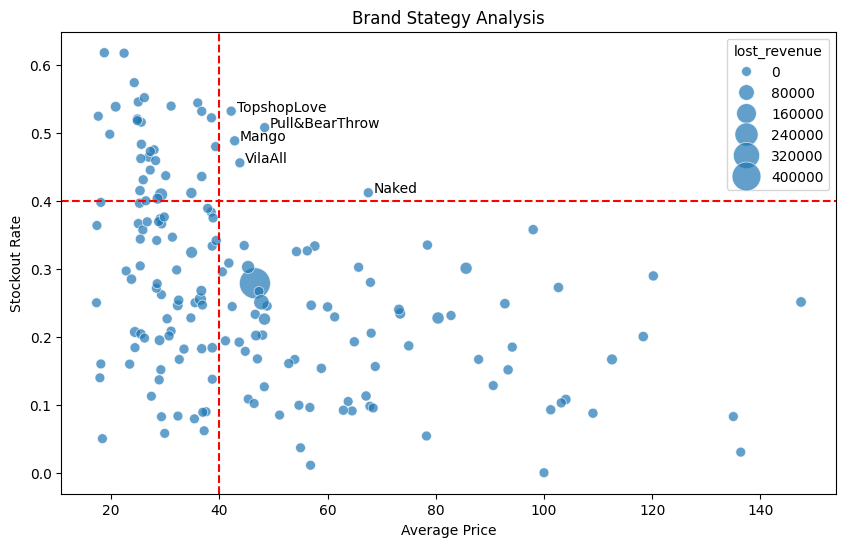

In [ ]:
brand_strategy=df_clean.groupby('Brand').agg(
    {
        "price":"mean",
        "Stockout Count":"mean",
        "Stockout Rate":"mean",
        "lost_revenue":"sum",
        "name":"count"
    }
).reset_index()

brand_strategy=brand_strategy[brand_strategy['name']>10]

plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_strategy,
                x='price',
                y='Stockout Rate',
                size='lost_revenue',
                sizes=(50,500),
                alpha=0.7,
                palette='viridis')

winners=brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout Rate']>0.4)
]

for i in range(len(winners)):
  plt.text(
      winners.iloc[i]['price']+1,
      winners.iloc[i]['Stockout Rate'],
      s=winners.iloc[i]['Brand'],
  )

plt.title('Brand Stategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40,color='red',linestyle='--')
plt.axhline(y=0.4,color='red',linestyle='--')
plt.show()